In [1]:
!pip install mthree

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 7.8 MB/s eta 0:00:007.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.6 MB/s eta 0:00:0031m10.7 MB/s eta 0:00:01
  Created wheel for runningman: filename=runningman-2.3.0-py3-none-any.whl size=20688 sha256=972fa7d6a9ecd98054f3513090817e76a20d06eb1eb0318de827653a4c17460c
  Stored in directory: /home/lpawela/.cache/pip/wheels/fe/e2/f9/d0b64e05745dbd68c6746279e5a551afd211820c4bb48da48b
Successfully built runningman


In [2]:
!pip freeze

annotated-types==0.7.0
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
arrow==1.3.0
asttokens==3.0.0
async-lru==2.0.5
attrs==25.3.0
babel==2.17.0
beautifulsoup4==4.13.3
bleach==6.2.0
certifi==2025.1.31
cffi==1.17.1
charset-normalizer==3.4.1
comm==0.2.2
contourpy==1.3.1
cryptography==44.0.2
cycler==0.12.1
Cython==3.0.12
debugpy==1.8.13
decorator==5.2.1
defusedxml==0.7.1
dill==0.3.9
executing==2.2.0
fastjsonschema==2.21.1
fonttools==4.57.0
fqdn==1.5.1
h11==0.14.0
httpcore==1.0.7
httpx==0.28.1
ibm-cloud-sdk-core==3.23.0
ibm-platform-services==0.63.0
idna==3.10
ipykernel==6.29.5
ipython==9.0.2
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.5
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
json5==0.12.0
jsonpointer==3.0.0
jsonschema==4.23.0
jsonschema-specifications==2024.10.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-lsp==2.2.5
jupyter_client==8.6.3
jupyter_core==5.7.2
jupyter_server==2.15.0
jupyter_server_terminals==0.5.3
jupyterlab==4.3.6
jupyterl

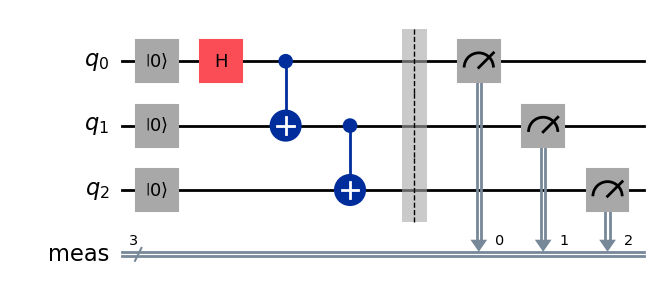

In [3]:
import numpy as np
from qiskit import *
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
import mthree

qc = QuantumCircuit(3)
qc.reset(range(3))
qc.h(0)
qc.cx(0,1)
qc.cx(1,2)
qc.measure_all()
qc.draw('mpl')

In [8]:
backend = FakeVigoV2()
mit = mthree.M3Mitigation(backend)
mit.cals_from_system(range(3))

In [10]:
trans_qc = transpile(qc, backend)
raw_counts = backend.run(trans_qc, shots=8192).result().get_counts()

In [11]:
raw_counts

{'101': 159,
 '001': 50,
 '110': 110,
 '100': 63,
 '010': 40,
 '000': 3970,
 '011': 120,
 '111': 3680}

In [13]:
prob_counts = {k: v/sum(raw_counts.values()) for k,v in raw_counts.items()}
prob_counts

{'101': 0.0194091796875,
 '001': 0.006103515625,
 '110': 0.013427734375,
 '100': 0.0076904296875,
 '010': 0.0048828125,
 '000': 0.484619140625,
 '011': 0.0146484375,
 '111': 0.44921875}

In [18]:
quasis = mit.apply_correction(raw_counts, range(3))
print('Expectation value:',quasis.expval("ZZZ"))

Expectation value: 0.02586430311203003


In [19]:
quasis

{'000': np.float32(0.5372585),
 '001': np.float32(-0.038504913),
 '010': np.float32(-0.0014851814),
 '011': np.float32(0.0039907363),
 '100': np.float32(0.0046086055),
 '101': np.float32(-0.00033421905),
 '110': np.float32(-0.027982831),
 '111': np.float32(0.5224493)}

In [20]:
all_zeros_proj = {'000': 1}
all_ones_proj = {'111': 1}
quasis.expval([all_zeros_proj, all_ones_proj])

array([0.5372585, 0.5224493], dtype=float32)

In [58]:
sum(quasis.values())

np.float32(0.9999999)

In [21]:
quasis.nearest_probability_distribution()

{'111': np.float32(0.4925954), '000': np.float32(0.5074046)}